# Style factor attribution

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats as scipy_stats
from pathlib import Path
import seaborn as sns
from matplotlib.ticker import MaxNLocator

## Configuration

In [2]:
# folder holding the msci index level files, monthly, gross total return, usd
data_dir = Path("../data/msci_data")

msci_index_codes = {
    "mkt": "891800",
    "value": "106063",
    "smallcap": "655061",
    "quality": "702788",
    "momentum": "703757"
}

# all 24 msci em country index codes, gross, usd, monthly, same source and settings
# as the five style indices above
country_index_codes = {
    "kor": "941000", "twn": "915800",
    "chn": "302400", "bra": "907600",
    "are": "133717", "col": "917000",
    "mex": "848400", "tur": "979200",
    "ind": "935600", "idn": "105767",
    "mys": "105768", "tha": "105769",
    "phl": "860800", "chl": "915200",
    "per": "960400", "zaf": "971000", 
    "pol": "961600", "grc": "930000",
    "hun": "934800", "qat": "133715",
    "kwt": "133713", "cze": "920000",
    "sau": "705405", "egy": "105766"
}

# number of principal components extracted from the full 24 country panel, used in
# place of the raw 24 returns so the regression stays identified
n_pca_components = 5

results_dir = Path("../results/transformer")
variants = ["linear", "per_feature", "ple", "periodic", "fourier"]

# strategy and scaling labels as they appear inside per_month_{variant}.csv
col_strategy = "strategy"
col_scaling = "scaling"
col_date = "eom"
col_return = "return"

strategies_to_check = ["long_only", "country_composite_long_only"]
scaling_to_use = "unscaled"

# newey west lag length for the hac standard errors, matches the six month rebalance cadence
hac_lags = 6

factor_cols = ["mkt", "value_spread", "smallcap_spread", "quality_spread", "momentum_spread"]

plots_dir = Path("../style_attribution_outputs/plots")
tables_dir = Path("../style_attribution_outputs/tables")
plots_dir.mkdir(parents = True, exist_ok = True)
tables_dir.mkdir(parents = True, exist_ok = True)

## Loading the MSCI style index levels

In [3]:
level_series = []
for label, code in msci_index_codes.items():
    matches = sorted(data_dir.glob(f"{code}*.xlsx"))
    if not matches:
        available = sorted(p.name for p in data_dir.glob("*.xlsx"))
        raise FileNotFoundError(f"no file starting with {code} found in {data_dir}, files present are {available}")
    if len(matches) > 1:
        raise ValueError(f"more than one file starting with {code} found in {data_dir}, matches are {[m.name for m in matches]}")
    path = matches[0]

    raw = pd.read_excel(path, sheet_name = "Performance Data", header = None)
    header_row = raw.index[raw[0] == "Date"][0]
    data = raw.iloc[header_row + 1:, [0, 1]].copy()
    data.columns = ["date", label + "_level"]
    data = data.dropna(subset = ["date", label + "_level"])
    data["date"] = pd.to_datetime(data["date"])
    data[label + "_level"] = pd.to_numeric(data[label + "_level"])
    data["month"] = data["date"].dt.to_period("M")
    series = data.set_index("month")[label + "_level"]
    level_series.append(series)

levels = pd.concat(level_series, axis = 1).sort_index()
print(levels.shape)
print(levels.index.is_monotonic_increasing)
print(levels.tail())

(354, 5)
True
           mkt_level  value_level  smallcap_level  quality_level  \
month                                                              
2026-02  4403.390871   758.292206     2890.747376    2337.038333   
2026-03  3829.716868   661.373136     2569.907678    2097.165998   
2026-04  4393.809101   744.624542     2915.246334    2497.719362   
2026-05  4820.314213   820.540023     3013.801374    2699.819921   
2026-06  4754.562221   805.626656     2925.852132    2575.441903   

         momentum_level  
month                    
2026-02    19977.385612  
2026-03    16176.609720  
2026-04    21123.794979  
2026-05    26484.768379  
2026-06    26667.309880  


## Computing monthly returns and the four style spread factors

In [4]:
# risk free rate, fred one month treasury constant maturity rate, daily, annualised per cent
rf_raw = pd.read_csv(data_dir / "DGS1MO.csv")
rf_raw["observation_date"] = pd.to_datetime(rf_raw["observation_date"])
rf_raw["DGS1MO"] = pd.to_numeric(rf_raw["DGS1MO"], errors = "coerce")
rf_raw["month"] = rf_raw["observation_date"].dt.to_period("M")

rf = rf_raw.dropna(subset = ["DGS1MO"]).groupby("month")["DGS1MO"].last()
rf = (rf / 100.0) / 12.0
rf.name = "rf"

returns = levels.pct_change()
returns.columns = [c.replace("_level", "_ret") for c in returns.columns]

# long only style factor construction, following the aqr and israel and ross convention. the
# market factor is the emerging markets index return in excess of the risk free rate. each style
# factor is the style index return minus the market index return, namely a self financing tilt of
# the style index against the market. the risk free rate cancels inside each style spread by
# construction, so this equals taking the style index in excess of the market factor
factors = pd.DataFrame(index = returns.index)
factors["mkt"] = returns["mkt_ret"] - rf
factors["value_spread"] = returns["value_ret"] - returns["mkt_ret"]
factors["smallcap_spread"] = returns["smallcap_ret"] - returns["mkt_ret"]
factors["quality_spread"] = returns["quality_ret"] - returns["mkt_ret"]
factors["momentum_spread"] = returns["momentum_ret"] - returns["mkt_ret"]
factors = factors.dropna()

factors.to_csv(tables_dir / "msci_style_factors.csv")
print(factors.describe().round(4).to_string())


            mkt  value_spread  smallcap_spread  quality_spread  momentum_spread
count  300.0000      300.0000         300.0000        300.0000         300.0000
mean     0.0083        0.0001           0.0007          0.0004           0.0031
std      0.0595        0.0091           0.0208          0.0149           0.0265
min     -0.2736       -0.0251          -0.0769         -0.0620          -0.1034
25%     -0.0252       -0.0059          -0.0123         -0.0076          -0.0089
50%      0.0078       -0.0003           0.0003          0.0003           0.0021
75%      0.0440        0.0051           0.0134          0.0098           0.0164
max      0.1713        0.0359           0.0598          0.0437           0.1585


## Results, all five variants

In [5]:
all_summaries = []
cached_runs = []

for variant in variants:
    for strategy in strategies_to_check:
        path = results_dir / f"per_month_{variant}.csv"
        if not path.exists():
            print(f"skipping {variant}, {strategy}, per_month csv not found")
            continue

        df = pd.read_csv(path)
        missing_cols = [c for c in [col_strategy, col_scaling, col_date, col_return] if c not in df.columns]
        if missing_cols:
            raise KeyError(f"columns {missing_cols} not found, available columns are {list(df.columns)}")

        mask = (df[col_strategy] == strategy) & (df[col_scaling] == scaling_to_use)
        filtered = df.loc[mask, [col_date, col_return]].copy()
        if filtered.empty:
            available_strategies = df[col_strategy].unique().tolist()
            available_scalings = df[col_scaling].unique().tolist()
            raise ValueError(f"no rows for strategy {strategy}, scaling {scaling_to_use}, available strategies are {available_strategies}, available scalings are {available_scalings}")

        filtered["date"] = pd.to_datetime(filtered[col_date])
        filtered["month"] = filtered["date"].dt.to_period("M")
        portfolio_return = filtered.set_index("month")[col_return]
        portfolio_return.name = "portfolio_return"
        # portfolio_return is already an excess return from the jkp pipeline, whose
        # target is ret_exc_lead1m, so no risk free adjustment is applied to the
        # dependent variable and it shares one basis with the excess market factor

        merged = factors.join(portfolio_return, how = "inner").dropna()

        # cumulative wealth and drawdown
        wealth = (1 + merged["portfolio_return"]).cumprod()
        drawdown = (wealth - wealth.cummax()) / wealth.cummax()
        max_drawdown = float(drawdown.min())
        print(f"max drawdown, {variant}, {strategy}, {max_drawdown:.4f}")

        # style regression, ols with newey west standard errors
        y = merged["portfolio_return"]
        x = sm.add_constant(merged[factor_cols])
        results = sm.OLS(y, x).fit(cov_type = "HAC", cov_kwds = {"maxlags": hac_lags})

        regression_labels = ["alpha (monthly)", "mkt", "value", "small cap", "quality", "momentum"]
        summary = pd.DataFrame({
            "factor": regression_labels,
            "loading": results.params.values.round(4),
            "t_stat": results.tvalues.values.round(2),
            "p_value": results.pvalues.values.round(3)
        })
        alpha_annualised = results.params["const"] * 12
        print(f"variant {variant}, strategy {strategy}, n_obs {int(results.nobs)}, r squared {results.rsquared:.3f}")
        print(summary.to_string(index = False))
        print(f"annualised alpha, simple x12, {alpha_annualised:.4f}")

        # market beta stability by year
        yearly = merged.copy()
        yearly["year"] = yearly.index.year
        yearly_rows = []
        for year, group in yearly.groupby("year"):
            # a variance with ddof = 1 is undefined on a single observation, which
            # occurs for the partial year at the end of the window, so such years are
            # reported without a beta rather than producing a divide by zero
            if len(group) < 2:
                yearly_rows.append({"year": year, "n_obs": len(group), "beta_mkt": np.nan, "corr_mkt": np.nan})
                continue
            beta = group["mkt"].cov(group["portfolio_return"]) / group["mkt"].var()
            corr = group["mkt"].corr(group["portfolio_return"])
            yearly_rows.append({"year": year, "n_obs": len(group), "beta_mkt": beta, "corr_mkt": corr})
        yearly_table = pd.DataFrame(yearly_rows)
        print(yearly_table.round(3).to_string(index = False))
        beta_std = yearly_table["beta_mkt"].std()
        sign_changes = (yearly_table["beta_mkt"].min() < 0) and (yearly_table["beta_mkt"].max() > 0)
        if sign_changes:
            print(f"note, {variant} {strategy}, yearly market beta changes sign across the window")

        # style loading directions
        direction_labels = ["market", "value", "small cap", "quality", "momentum"]
        betas = results.params[factor_cols].values
        direction_table = pd.DataFrame({
            "factor": direction_labels,
            "loading": betas.round(4),
            "direction": ["positive" if b >= 0 else "negative" for b in betas]
        })
        print(direction_table.to_string(index = False))

        # upside and downside capture
        up = merged[merged["mkt"] > 0]
        down = merged[merged["mkt"] < 0]
        up_portfolio = (1 + up["portfolio_return"]).prod() - 1
        up_market = (1 + up["mkt"]).prod() - 1
        down_portfolio = (1 + down["portfolio_return"]).prod() - 1
        down_market = (1 + down["mkt"]).prod() - 1
        upside_capture = up_portfolio / up_market * 100
        downside_capture = down_portfolio / down_market * 100
        print(f"upside capture {upside_capture:.1f} percent over {len(up)} months, downside capture {downside_capture:.1f} percent over {len(down)} months")

        all_summaries.append({
            "variant": variant,
            "strategy": strategy,
            "n_obs": int(results.nobs),
            "r_squared": results.rsquared,
            "alpha_monthly": results.params["const"],
            "alpha_annualised": alpha_annualised,
            "beta_mkt": results.params["mkt"],
            "beta_value": results.params["value_spread"],
            "beta_smallcap": results.params["smallcap_spread"],
            "beta_quality": results.params["quality_spread"],
            "beta_momentum": results.params["momentum_spread"],
            "upside_capture": upside_capture,
            "downside_capture": downside_capture,
            "max_drawdown": max_drawdown,
            "beta_mkt_year_std": beta_std,
            "beta_mkt_sign_changes": sign_changes
        })

        cached_runs.append({
            "variant": variant,
            "strategy": strategy,
            "results": results,
            "merged": merged,
            "wealth": wealth,
            "drawdown": drawdown,
            "upside_capture": upside_capture,
            "downside_capture": downside_capture
        })

summary_table = pd.DataFrame(all_summaries)
summary_table.to_csv(tables_dir / "style_attribution_summary.csv", index = False)
print(summary_table.round(4).to_string(index = False))

max drawdown, linear, long_only, -0.0929
variant linear, strategy long_only, n_obs 60, r squared 0.433
         factor  loading  t_stat  p_value
alpha (monthly)   0.0230    5.42    0.000
            mkt   0.6810    5.00    0.000
          value   1.8479    2.47    0.014
      small cap   0.8636    5.50    0.000
        quality  -0.3715   -1.43    0.154
       momentum  -0.1310   -0.79    0.430
annualised alpha, simple x12, 0.2759
 year  n_obs  beta_mkt  corr_mkt
 2021     11    -0.149    -0.082
 2022     12     0.593     0.711
 2023     12     0.453     0.814
 2024     12    -0.051    -0.064
 2025     12    -0.051    -0.061
 2026      1       NaN       NaN
note, linear long_only, yearly market beta changes sign across the window
   factor  loading direction
   market   0.6810  positive
    value   1.8479  positive
small cap   0.8636  positive
  quality  -0.3715  negative
 momentum  -0.1310  negative
upside capture 176.5 percent over 35 months, downside capture -83.0 percent over 25 mon

## Testing country concentration as an additional driver

In [6]:
country_level_series = []
for label, code in country_index_codes.items():
    matches = sorted(data_dir.glob(f"{code}*.xlsx"))
    if not matches:
        available = sorted(p.name for p in data_dir.glob("*.xlsx"))
        raise FileNotFoundError(f"no file starting with {code} found in {data_dir}, files present are {available}")
    if len(matches) > 1:
        raise ValueError(f"more than one file starting with {code} found in {data_dir}, matches are {[m.name for m in matches]}")
    path = matches[0]

    raw = pd.read_excel(path, sheet_name = "Performance Data", header = None)
    header_row = raw.index[raw[0] == "Date"][0]
    data = raw.iloc[header_row + 1:, [0, 1]].copy()
    data.columns = ["date", label + "_level"]
    data = data.dropna(subset = ["date", label + "_level"])
    data["date"] = pd.to_datetime(data["date"])
    data[label + "_level"] = pd.to_numeric(data[label + "_level"])
    data["month"] = data["date"].dt.to_period("M")
    series = data.set_index("month")[label + "_level"]
    country_level_series.append(series)

country_levels = pd.concat(country_level_series, axis = 1).sort_index()
country_returns = country_levels.pct_change()
country_returns.columns = [c.replace("_level", "_ret") for c in country_returns.columns]
country_returns.to_csv(tables_dir / "msci_country_returns_24.csv")
print(country_returns.shape)
print(country_returns.describe().round(4).to_string())

(332, 24)
        kor_ret   twn_ret   chn_ret   bra_ret   are_ret   col_ret   mex_ret   tur_ret   ind_ret   idn_ret   mys_ret   tha_ret   phl_ret   chl_ret   per_ret   zaf_ret   pol_ret   grc_ret   hun_ret   qat_ret   kwt_ret   cze_ret   sau_ret   egy_ret
count  331.0000  331.0000  331.0000  331.0000  254.0000  331.0000  331.0000  331.0000  331.0000  331.0000  331.0000  331.0000  331.0000  331.0000  331.0000  331.0000  331.0000  331.0000  331.0000  254.0000  254.0000  331.0000  143.0000  331.0000
mean     0.0141    0.0114    0.0081    0.0129    0.0057    0.0161    0.0107    0.0131    0.0118    0.0109    0.0081    0.0106    0.0058    0.0084    0.0162    0.0106    0.0098    0.0009    0.0124    0.0054    0.0058    0.0140    0.0048    0.0120
std      0.0920    0.0736    0.0812    0.1019    0.0852    0.0934    0.0693    0.1282    0.0769    0.0932    0.0563    0.0828    0.0682    0.0675    0.0814    0.0737    0.0914    0.1008    0.0926    0.0679    0.0562    0.0757    0.0562    0.0952
min   

### PCA test, all 24 countries

In [7]:
country_returns_common = country_returns.dropna()
standardised = (country_returns_common - country_returns_common.mean()) / country_returns_common.std()

u, s, vt = np.linalg.svd(standardised.values, full_matrices = False)
explained_variance_ratio = (s ** 2) / (s ** 2).sum()

pca_scores = pd.DataFrame(
    u[:, :n_pca_components] * s[:n_pca_components],
    index = country_returns_common.index,
    columns = [f"pc{i + 1}" for i in range(n_pca_components)]
)
pca_cols = list(pca_scores.columns)

print("explained variance ratio, first", n_pca_components, "components")
print(pd.Series(explained_variance_ratio[:n_pca_components], index = pca_cols).round(4).to_string())
print("cumulative:", round(explained_variance_ratio[:n_pca_components].sum(), 4))

explained variance ratio, first 5 components
pc1    0.4612
pc2    0.0663
pc3    0.0530
pc4    0.0493
pc5    0.0454
cumulative: 0.6752


In [8]:
country_labels_24: list[str] = [label.upper() for label in country_index_codes.keys()]
loadings = pd.DataFrame(vt[:n_pca_components].T.tolist(), index = country_labels_24, columns = pca_cols)

all_loadings_rows = []
for pc in pca_cols:
    ranked = loadings[pc].abs().sort_values(ascending = False).index
    for rank, country in enumerate(ranked, start = 1):
        cell_value = loadings.loc[[country], pc].to_numpy()
        all_loadings_rows.append({
            "component": pc,
            "rank": rank,
            "country": country,
            "loading": round(float(cell_value[0]), 3)
        })

all_loadings_table = pd.DataFrame(all_loadings_rows)
all_loadings_table.to_csv(tables_dir / "style_attribution_pca_country_loadings.csv", index = False)
print(all_loadings_table.to_string(index = False))

component  rank country  loading
      pc1     1     ZAF    0.252
      pc1     2     POL    0.237
      pc1     3     MEX    0.234
      pc1     4     PER    0.232
      pc1     5     MYS    0.231
      pc1     6     BRA    0.229
      pc1     7     CHL    0.221
      pc1     8     HUN    0.220
      pc1     9     COL    0.220
      pc1    10     CZE    0.220
      pc1    11     THA    0.214
      pc1    12     PHL    0.209
      pc1    13     GRC    0.203
      pc1    14     IND    0.203
      pc1    15     KOR    0.202
      pc1    16     TWN    0.199
      pc1    17     ARE    0.194
      pc1    18     IDN    0.182
      pc1    19     QAT    0.174
      pc1    20     KWT    0.173
      pc1    21     TUR    0.157
      pc1    22     CHN    0.152
      pc1    23     SAU    0.150
      pc1    24     EGY    0.134
      pc2     1     KWT    0.429
      pc2     2     SAU    0.409
      pc2     3     ARE    0.369
      pc2     4     TWN   -0.303
      pc2     5     QAT    0.292
      pc2 

In [9]:
pca_factors = factors.join(pca_scores, how = "inner").dropna()

pca_country_summaries = []

for variant in variants:
    for strategy in strategies_to_check:
        path = results_dir / f"per_month_{variant}.csv"
        if not path.exists():
            print(f"skipping {variant}, {strategy}, per_month csv not found")
            continue

        df = pd.read_csv(path)
        missing_cols = [c for c in [col_strategy, col_scaling, col_date, col_return] if c not in df.columns]
        if missing_cols:
            raise KeyError(f"columns {missing_cols} not found, available columns are {list(df.columns)}")

        mask = (df[col_strategy] == strategy) & (df[col_scaling] == scaling_to_use)
        filtered = df.loc[mask, [col_date, col_return]].copy()
        if filtered.empty:
            available_strategies = df[col_strategy].unique().tolist()
            available_scalings = df[col_scaling].unique().tolist()
            raise ValueError(f"no rows for strategy {strategy}, scaling {scaling_to_use}, available strategies are {available_strategies}, available scalings are {available_scalings}")

        filtered["date"] = pd.to_datetime(filtered[col_date])
        filtered["month"] = filtered["date"].dt.to_period("M")
        portfolio_return = filtered.set_index("month")[col_return]
        portfolio_return.name = "portfolio_return"
        # portfolio_return is already an excess return from the jkp pipeline, whose
        # target is ret_exc_lead1m, so no risk free adjustment is applied to the
        # dependent variable and it shares one basis with the excess market factor

        merged = pca_factors.join(portfolio_return, how = "inner").dropna()

        y = merged["portfolio_return"]
        x_restricted = sm.add_constant(merged[factor_cols])
        x_full = sm.add_constant(merged[factor_cols + pca_cols])

        restricted_plain = sm.OLS(y, x_restricted).fit()
        full_plain = sm.OLS(y, x_full).fit()
        full_hac = sm.OLS(y, x_full).fit(cov_type = "HAC", cov_kwds = {"maxlags": hac_lags})

        q = len(pca_cols)
        n = int(full_plain.nobs)
        k = x_full.shape[1]
        f_stat = ((restricted_plain.ssr - full_plain.ssr) / q) / (full_plain.ssr / (n - k))
        p_value = 1 - scipy_stats.f.cdf(f_stat, q, n - k)
        baseline_r2 = restricted_plain.rsquared
        extended_r2 = full_plain.rsquared

        print(f"variant {variant}, strategy {strategy}, 24 country pca, baseline r squared {baseline_r2:.3f}, extended r squared {extended_r2:.3f}, incremental r squared {extended_r2 - baseline_r2:.3f}")
        print(f"joint test on {q} extra regressors, f statistic {f_stat:.2f}, p value {p_value:.3f}")
        pc_table = pd.DataFrame({
            "regressor": pca_cols,
            "loading": full_hac.params[pca_cols].values.round(4),
            "t_stat": full_hac.tvalues[pca_cols].values.round(2),
            "p_value": full_hac.pvalues[pca_cols].values.round(3)
        })
        print(pc_table.to_string(index = False))

        row = {
            "variant": variant,
            "strategy": strategy,
            "baseline_r_squared": baseline_r2,
            "extended_r_squared": extended_r2,
            "incremental_r_squared": extended_r2 - baseline_r2,
            "f_stat": f_stat,
            "p_value": p_value
        }
        for _, pc_row in pc_table.iterrows():
            row[f"beta_{pc_row['regressor'].lower()}"] = pc_row["loading"]
        pca_country_summaries.append(row)

pca_country_summary_table = pd.DataFrame(pca_country_summaries)
pca_country_summary_table.to_csv(tables_dir / "style_attribution_pca_country_test.csv", index = False)
print(pca_country_summary_table.round(4).to_string(index = False))

variant linear, strategy long_only, 24 country pca, baseline r squared 0.433, extended r squared 0.473, incremental r squared 0.040
joint test on 5 extra regressors, f statistic 0.75, p value 0.588
regressor  loading  t_stat  p_value
      pc1   0.0076    1.57    0.115
      pc2  -0.0054   -0.87    0.384
      pc3   0.0021    0.73    0.466
      pc4  -0.0066   -1.84    0.066
      pc5   0.0014    0.23    0.818
variant linear, strategy country_composite_long_only, 24 country pca, baseline r squared 0.664, extended r squared 0.708, incremental r squared 0.045
joint test on 5 extra regressors, f statistic 1.50, p value 0.208
regressor  loading  t_stat  p_value
      pc1  -0.0038   -2.63    0.008
      pc2   0.0071    2.81    0.005
      pc3  -0.0013   -0.60    0.549
      pc4   0.0008    0.40    0.689
      pc5   0.0008    0.33    0.738
variant per_feature, strategy long_only, 24 country pca, baseline r squared 0.224, extended r squared 0.323, incremental r squared 0.099
joint test on 5 e

## Charts

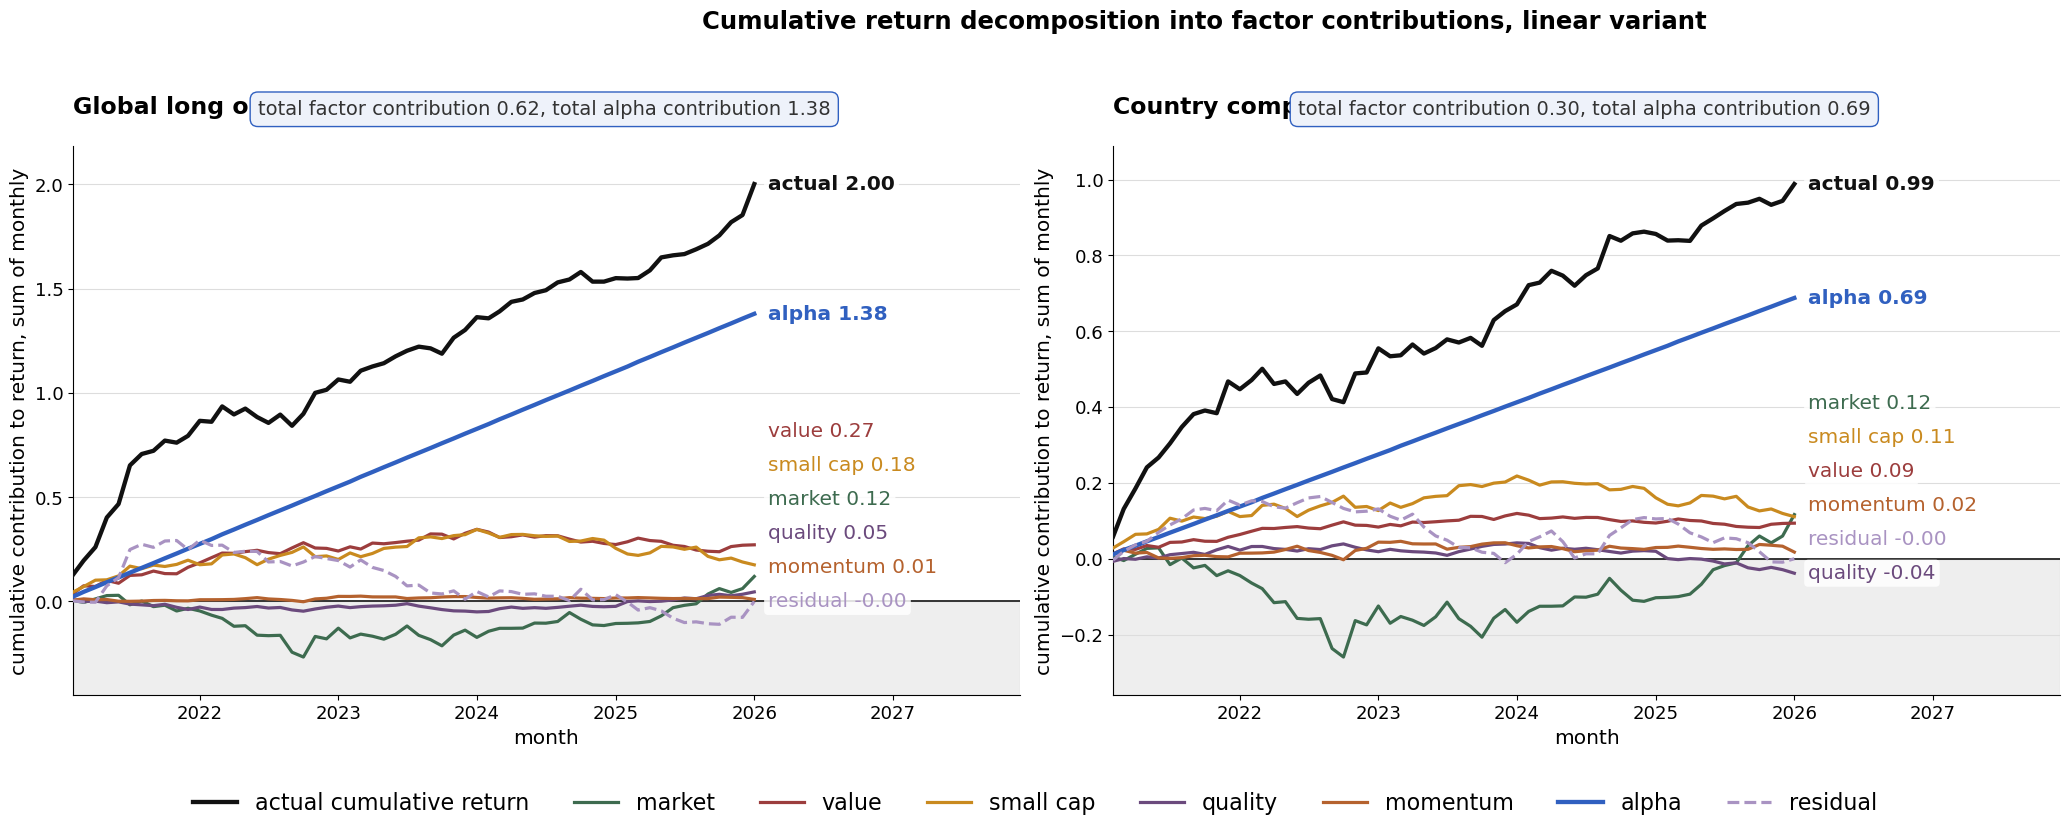

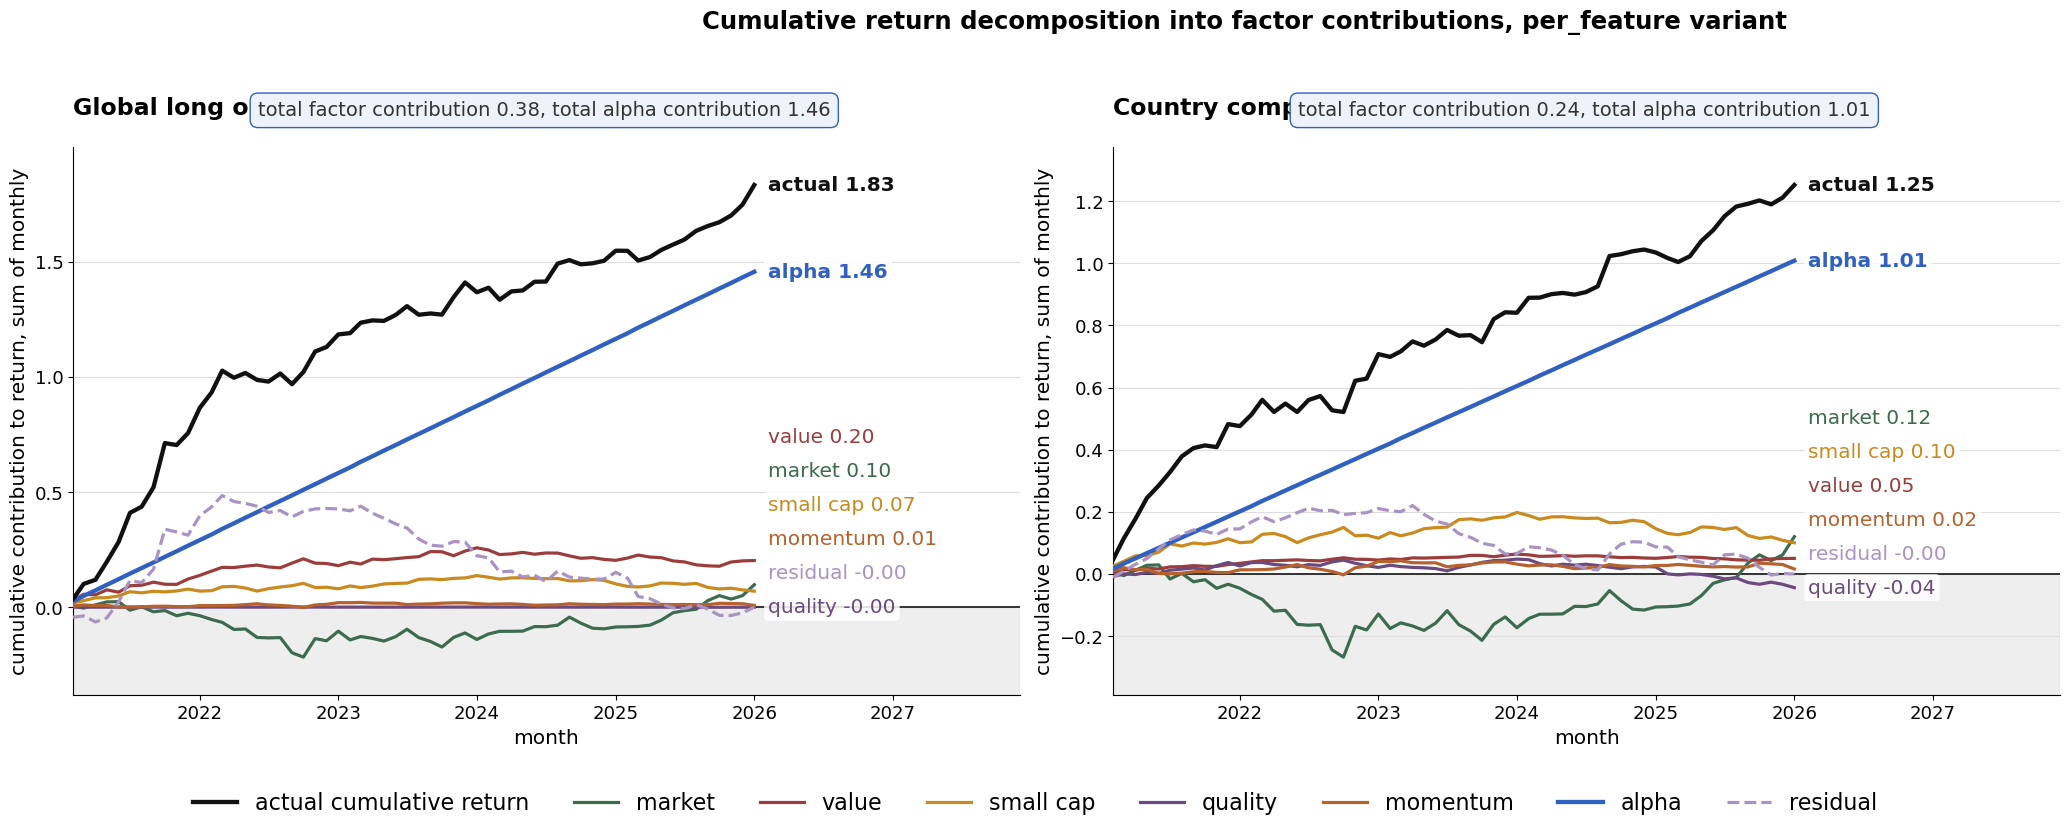

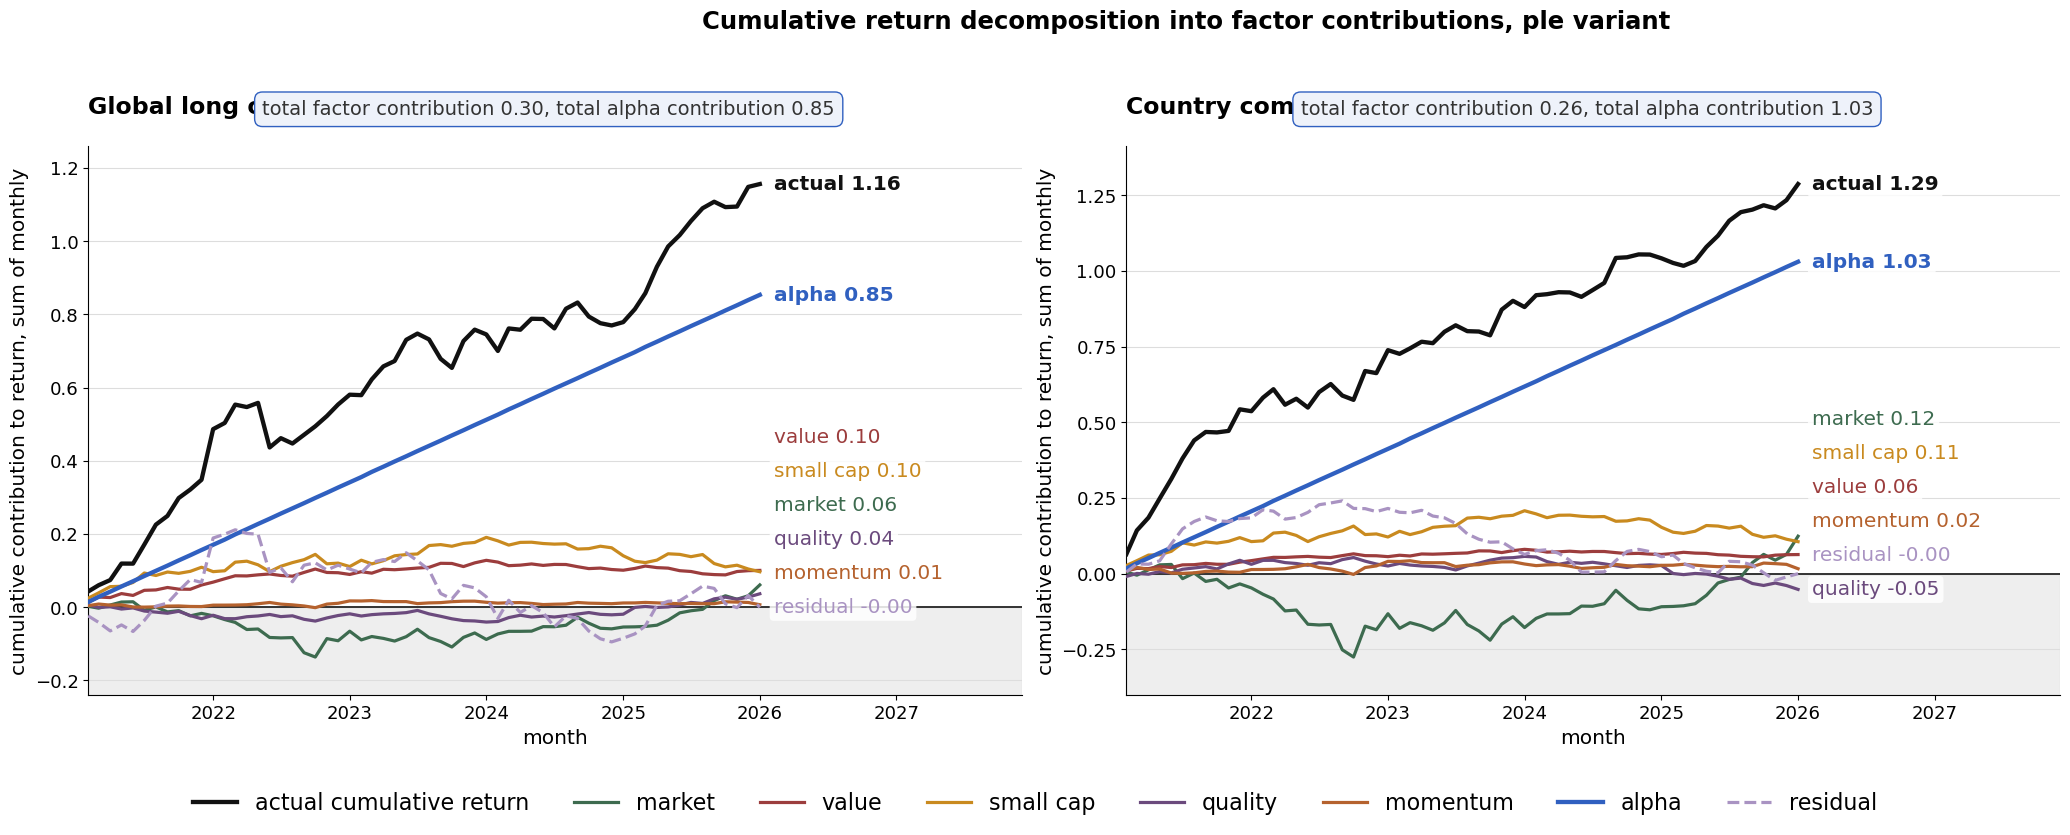

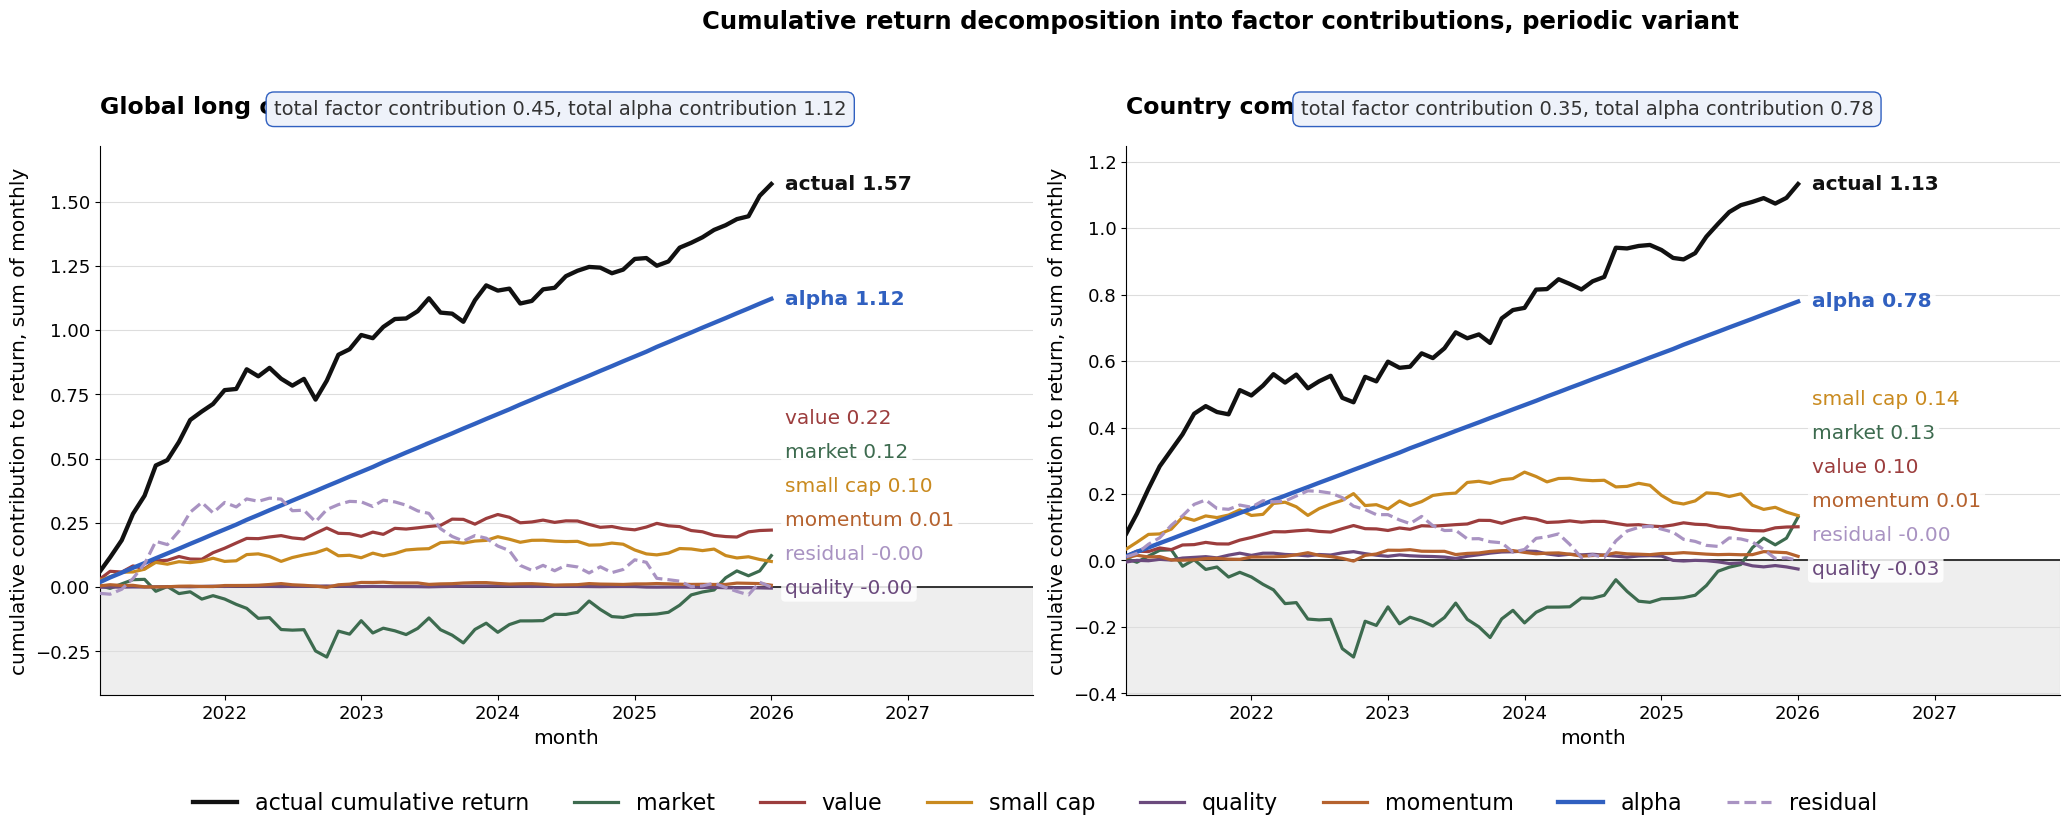

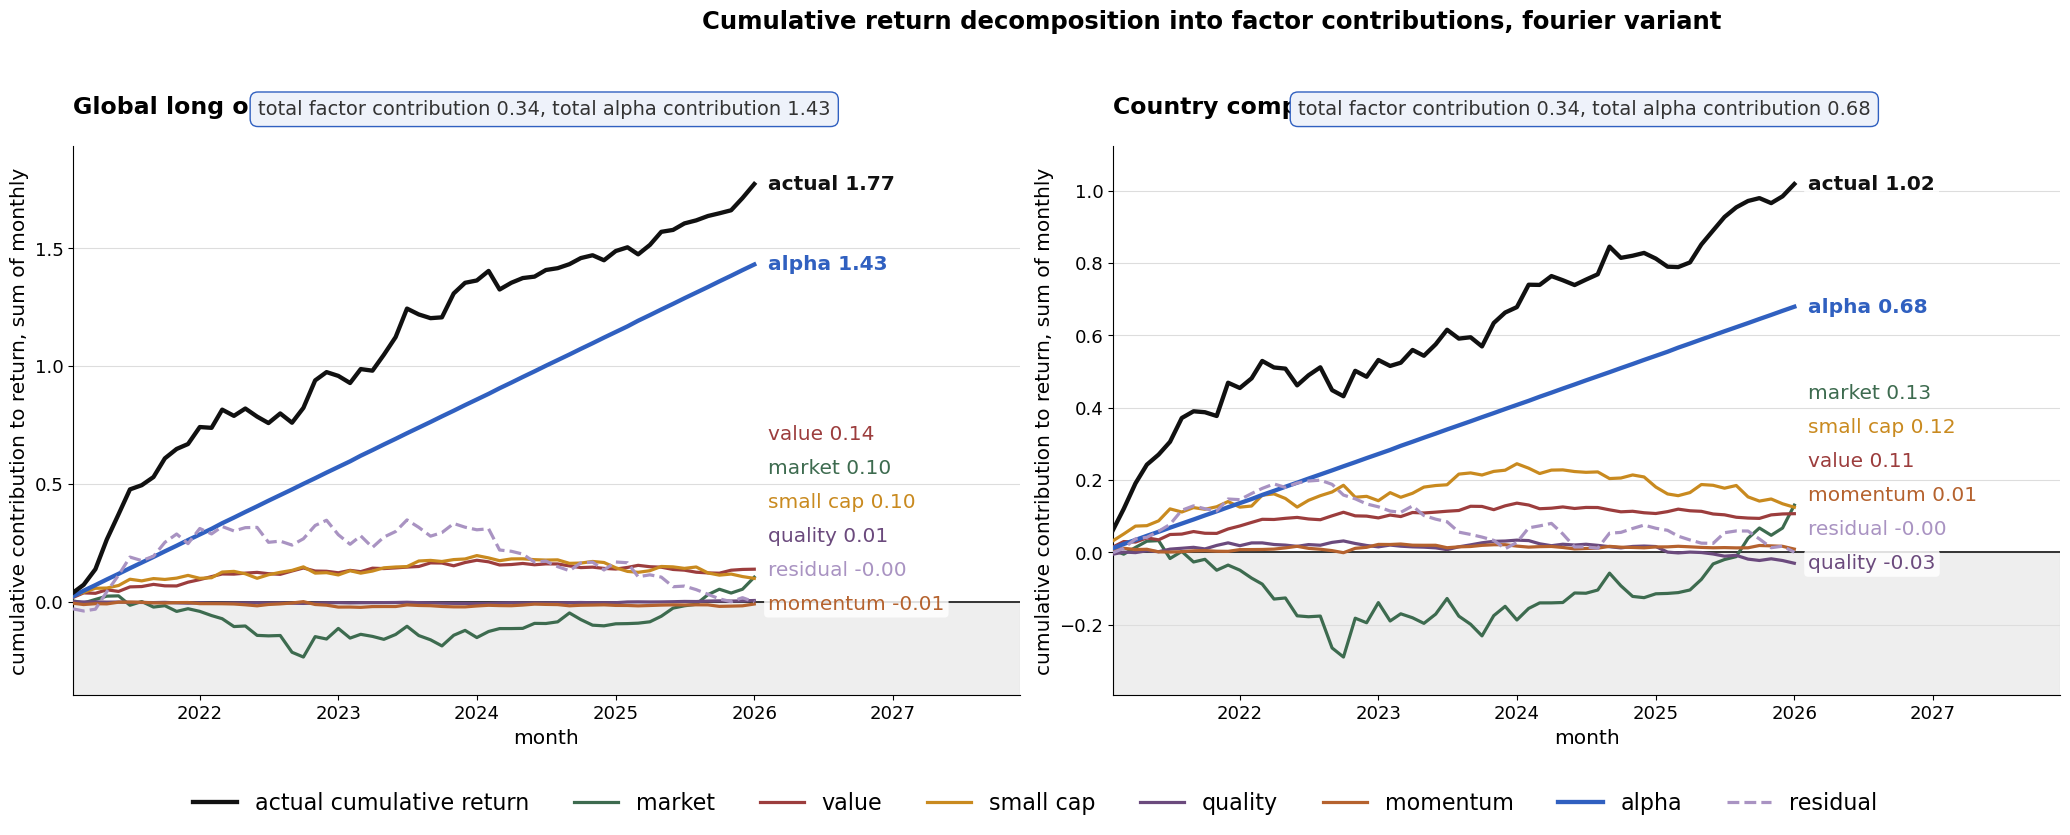

In [10]:
plot_labels = ["market", "value", "small cap", "quality", "momentum"]
line_colors = {
    "market": "#3d6b4f", "value": "#9c3d3d",
    "small cap": "#c98a1f", "quality": "#6b4a7d",
    "momentum": "#b5622e", "alpha": "#3060c0",
    "residual": "#a993c2"
}
strategy_titles = {
    "long_only": "Global long only",
    "country_composite_long_only": "Country composite long only"
}

for variant in variants:
    runs = [r for r in cached_runs if r["variant"] == variant]
    if not runs:
        continue

    fig, axes = plt.subplots(1, len(runs), figsize = (10.4 * len(runs), 8.7), squeeze = False)
    axes = axes[0]

    for ax, run in zip(axes, runs):
        merged = run["merged"]
        results = run["results"]

        # each factor contributes its loading multiplied by that factor realised
        # return, the intercept contributes a constant every month, and the residual
        # is carried explicitly so the components sum to the realised return exactly
        contributions = pd.DataFrame(index = merged.index)
        for col, label in zip(factor_cols, plot_labels):
            contributions[label] = results.params[col] * merged[col]
        contributions["alpha"] = results.params["const"]
        contributions["residual"] = results.resid

        cumulative = contributions.cumsum()
        timestamps = cumulative.index.to_timestamp()

        actual = merged["portfolio_return"].cumsum()
        ax.plot(timestamps, actual.values, color = "#111111", linewidth = 3.1,
                label = "actual cumulative return", zorder = 5)

        # each component is drawn from zero rather than stacked, so its sign and
        # magnitude can be read directly against the zero line
        series_labels = plot_labels + ["alpha", "residual"]
        for label in series_labels:
            values = cumulative[label].values
            style = "dashed" if label == "residual" else "solid"
            width = 3.1 if label == "alpha" else 2.3
            ax.plot(timestamps, values, color = line_colors[label], linewidth = width,
                    linestyle = style, label = label, zorder = 4)

        # plain light grey marks the negative half plane only
        ax.axhspan(-1e6, 0, color = "#c9c9c9", alpha = 0.30, zorder = 0)
        ax.axhline(0, color = "#333333", linewidth = 1.4, zorder = 1)

        span = cumulative[series_labels].values
        low = min(span.min(), actual.min(), 0)
        high = max(span.max(), actual.max())
        pad = (high - low) * 0.08
        ax.set_ylim(low - pad, high + pad)
        ax.set_xlim(timestamps[0], timestamps[-1] + pd.Timedelta(days = 700))
        final_points = [(label, cumulative[label].iloc[-1]) for label in series_labels]
        final_points.append(("actual", actual.iloc[-1]))
        final_points.sort(key = lambda pair: pair[1])
        min_gap = (high - low + 2 * pad) * 0.062
        placed = []
        for label, value in final_points:
            position = value
            if placed and position - placed[-1][1] < min_gap:
                position = placed[-1][1] + min_gap
            placed.append((label, position, value))
        for label, position, value in placed:
            colour = "#111111" if label == "actual" else line_colors[label]
            weight = "bold" if label in ("actual", "alpha") else "normal"
            ax.annotate(f"{label} {value:.2f}", xy = (timestamps[-1], position),
                        xytext = (10, 0), textcoords = "offset points",
                        fontsize = 14.5, color = colour, va = "center", fontweight = weight,
                        bbox = dict(boxstyle = "round,pad=0.2", facecolor = "white",
                                    edgecolor = "none", alpha = 0.85))

        ax.text(0.0, 1.05, strategy_titles.get(run["strategy"], run["strategy"]),
                transform = ax.transAxes, ha = "left", va = "bottom",
                fontsize = 17, fontweight = "bold")
        ax.tick_params(labelsize = 13)
        ax.set_ylabel("cumulative contribution to return, sum of monthly", fontsize = 14.5)
        ax.set_xlabel("month", fontsize = 14.5)
        ax.grid(axis = "y", color = "#dddddd", linewidth = 0.8, zorder = 0)
        ax.set_axisbelow(True)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        total_factor = contributions[plot_labels].sum().sum()
        total_alpha = contributions["alpha"].sum()
        ax.text(0.8, 1.05,
                f"total factor contribution {total_factor:.2f}, total alpha contribution {total_alpha:.2f}",
                transform = ax.transAxes, ha = "right", va = "bottom", fontsize = 14, color = "#333333",
                bbox = dict(boxstyle = "round,pad=0.4", facecolor = "#eef2fa", edgecolor = "#3060c0"))

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc = "lower center", ncol = len(handles), frameon = False, fontsize = 16)
    fig.suptitle(f"Cumulative return decomposition into factor contributions, {variant} variant",
             fontsize = 17.5, fontweight = "bold",
             x= 0.34, y = 0.95, ha = "left")
    fig.tight_layout(rect = [0, 0.085, 1, 0.92])
    fig.savefig(plots_dir / f"factor_contribution_{variant}.png", dpi = 150)
    plt.show()

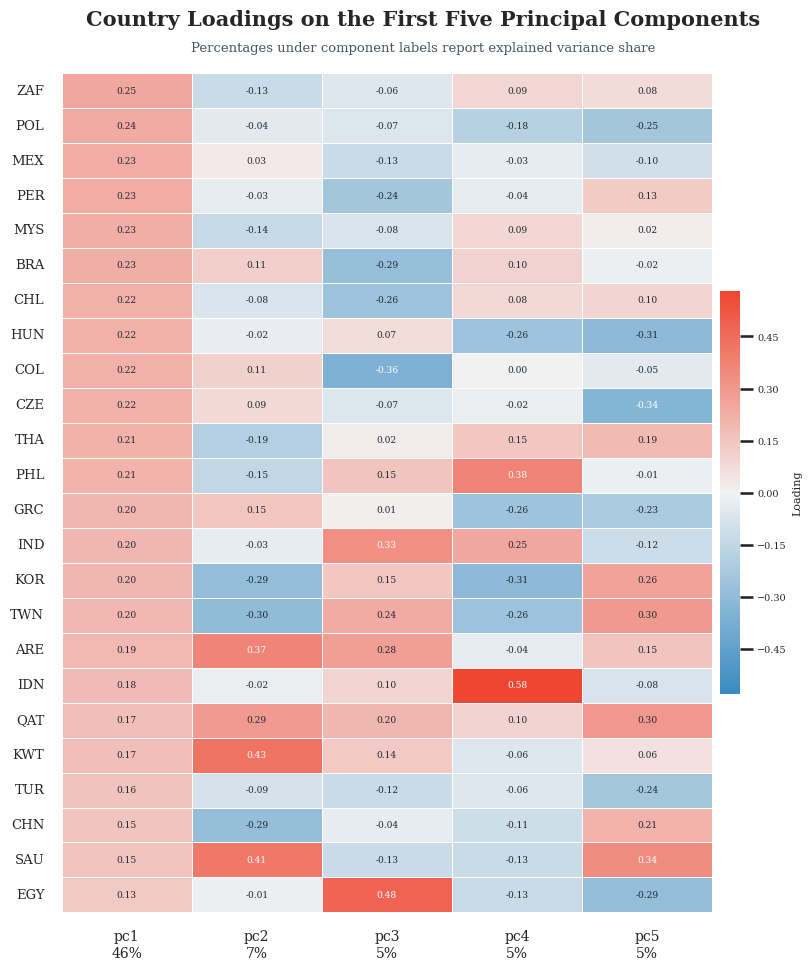

In [11]:
sns.set_theme(context="talk", style="white", font="serif")

order = loadings["pc1"].sort_values(ascending=False).index
loadings_sorted = loadings.loc[order]
limit = np.abs(loadings_sorted.values).max()
xtick_labels = [f"{c}\n{explained_variance_ratio[i]:.0%}" for i, c in enumerate(pca_cols)]
cmap = sns.diverging_palette(240, 15, s=85, l=55, center="light", as_cmap=True)

fig, ax = plt.subplots(figsize=(8.8, 10.4))

hm = sns.heatmap(loadings_sorted, ax=ax, cmap=cmap, vmin=-limit, vmax=limit, center=0, linewidths=0.45, linecolor="white", cbar_kws={"label": "Loading", "shrink": 0.48, "pad": 0.01})

for i in range(loadings_sorted.shape[0]):
    for j in range(loadings_sorted.shape[1]):
        value = loadings_sorted.iloc[i, j]
        ax.text(j + 0.5, i + 0.5, f"{value:.2f}", ha="center", va="center", fontsize=6.5, color="white" if abs(value) > limit * 0.55 else "#1f2933")

cbar = hm.collections[0].colorbar
cbar.ax.yaxis.set_major_locator(MaxNLocator(nbins=9))
cbar.ax.tick_params(labelsize=7)
cbar.ax.yaxis.label.set_size(8)

ax.set_xticklabels(xtick_labels, fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=9.5, rotation=0)
ax.set_xlabel("")
ax.set_ylabel("")

fig.suptitle("Country Loadings on the First Five Principal Components", fontsize=15, fontweight="bold", y=0.94)
fig.text(0.5, 0.9, "Percentages under component labels report explained variance share", ha="center", fontsize=9.5, color="#4A5568")

fig.tight_layout(rect=(0, 0, 1, 0.95))
fig.savefig(plots_dir / "pca_country_loadings_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

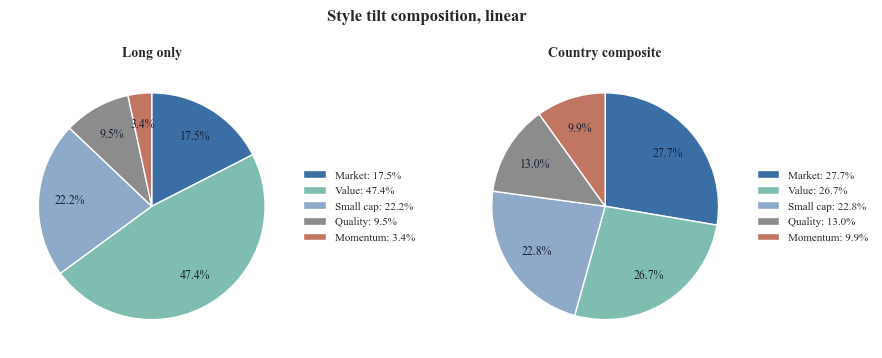

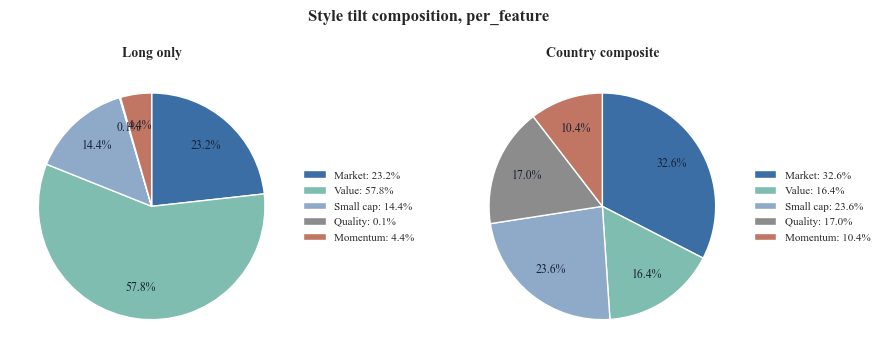

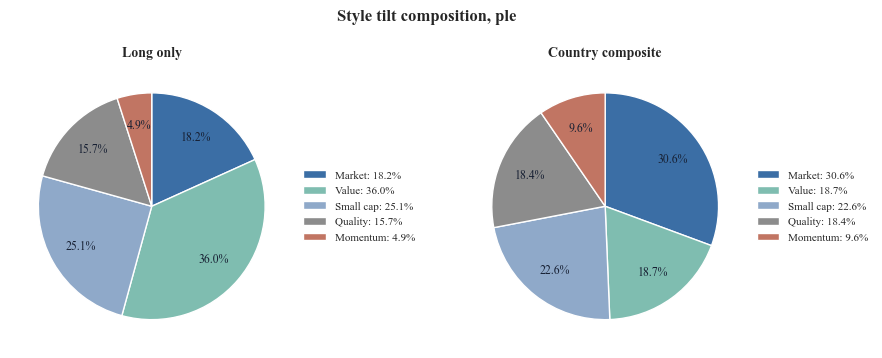

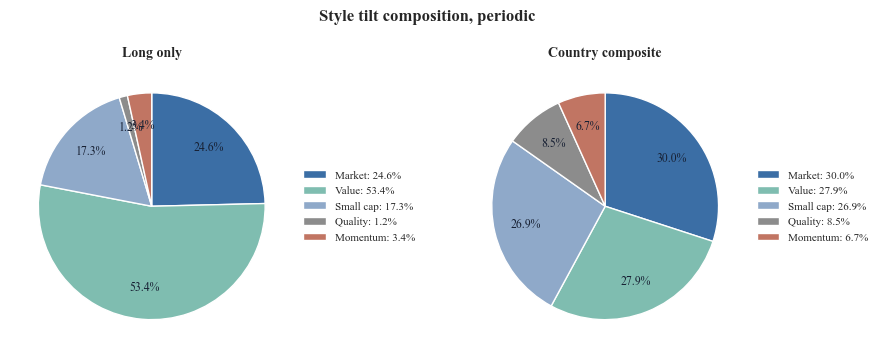

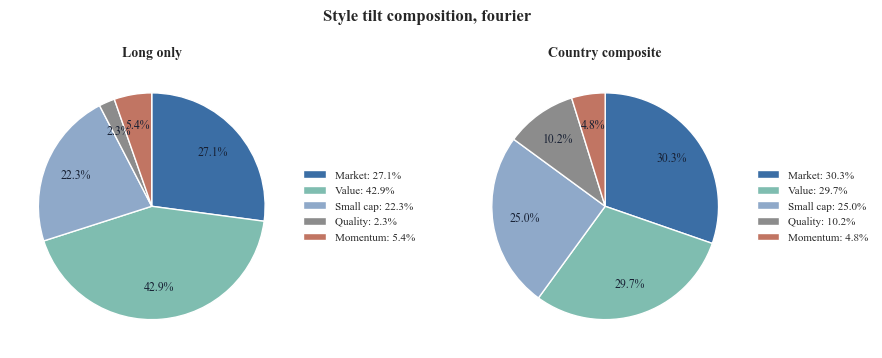

In [12]:
sns.set_theme(context="paper", style="white", font="serif")
plt.rcParams["font.serif"] = ["TeX Gyre Termes", "Liberation Serif", "Times New Roman", "DejaVu Serif"]

pie_labels = ["Market", "Value", "Small cap", "Quality", "Momentum"]
# same five colours used for the same five factors in the cumulative contribution
# chart, so a colour means the same thing everywhere in the dissertation rather
# than being re-picked per figure
pie_colors = ["#3b6ea5", "#7fbdb0", "#8fa9c9", "#8c8c8c", "#c17563"]
strategy_titles = {"long_only": "Long only", "country_composite_long_only": "Country composite"}

for variant in variants:
    fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.6))

    for ax, strategy in zip(axes, strategy_titles):
        run = next(r for r in cached_runs if r["variant"] == variant and r["strategy"] == strategy)
        shares = np.abs(run["results"].params[factor_cols].values)
        shares = shares / shares.sum()
        legend_labels = [f"{label}: {share:.1%}" for label, share in zip(pie_labels, shares)]

        wedges, _, _ = ax.pie(shares, colors=pie_colors, startangle=90, counterclock=False, autopct="%1.1f%%", pctdistance=0.72, wedgeprops={"edgecolor": "white", "linewidth": 1.0}, textprops={"fontsize": 8.5, "color": "#172033"})
        ax.legend(wedges, legend_labels, loc="center left", bbox_to_anchor=(1.0, 0.5), frameon=False, fontsize=8)
        ax.set_title(strategy_titles[strategy], fontsize=10, fontweight="bold")
        ax.set_aspect("equal")

    fig.suptitle(f"Style tilt composition, {variant}", fontsize=12, fontweight="bold")
    fig.tight_layout()
    fig.savefig(plots_dir / f"style_pie_strategy_comparison_{variant}.png", dpi=300, bbox_inches="tight")
    plt.show()

## Long only book concentration

The long only series produced by `portfolio_simulation_monthly` is a capped softmax portfolio over the whole cross section, not an equal weight top quintile. We measure its effective breadth by the inverse Herfindahl index, one over the sum of squared weights, which equals the name count for an equal weight book and falls sharply as weight concentrates under the five per cent cap. A low effective breadth accounts for the weak market correlation and the elevated intercept reported in the attribution above.

In [13]:
# concentration diagnostic for the long only book of every variant, the effective number of
# holdings is one over the sum of squared weights, computed per rebalance and summarised per variant
breadth_rows = []
for variant in variants:
    hpath = results_dir / f"holdings_{variant}.parquet"
    if not hpath.exists():
        print(f"{variant}, holdings file not found at {hpath}")
        continue
    hold = pd.read_parquet(hpath)
    mask = hold["portfolio"].isin(["long_only", "long_only_monthly"])
    if "leg" in hold.columns:
        mask = mask & (hold["leg"] == "long")
    lo = hold[mask].copy()
    if lo.empty:
        print(f"{variant}, no long only holdings rows")
        continue
    # normalise weights within each rebalance so the book sums to one and breadth is comparable
    lo["w"] = lo["weight"] / lo.groupby("rebalance_index")["weight"].transform("sum")
    for rb, g in lo.groupby("rebalance_index"):
        w = np.sort(g["w"].to_numpy(dtype = "float64"))
        breadth_rows.append({
            "variant": variant,
            "rebalance_index": int(rb),
            "n_names": int(w.size),
            "eff_n_holdings": float(1.0 / (w ** 2).sum()),
            "max_weight": float(w[-1]),
            "top5_weight": float(w[-5:].sum()),
        })

breadth = pd.DataFrame(breadth_rows)
breadth.to_csv(tables_dir / "book_breadth_by_rebalance.csv", index = False)

breadth_summary = breadth.groupby("variant").agg(
    median_n_names = ("n_names", "median"),
    median_eff_n_holdings = ("eff_n_holdings", "median"),
    median_max_weight = ("max_weight", "median"),
    median_top5_weight = ("top5_weight", "median"),
).reindex(variants).reset_index()
breadth_summary.to_csv(tables_dir / "book_breadth_summary.csv", index = False)
print(breadth_summary.round(3).to_string(index = False))


    variant  median_n_names  median_eff_n_holdings  median_max_weight  median_top5_weight
     linear         18523.0                 31.539               0.05                0.25
per_feature         18523.0                 32.147               0.05                0.25
        ple         18523.0                 29.142               0.05                0.25
   periodic         18523.0                 33.733               0.05                0.25
    fourier         18523.0                 29.840               0.05                0.25


## Book holdings and country composition

For every variant we list the firms held in the long only book together with their country, the time average country weights, and the most heavily weighted firms. The full detail is written to CSV under the tables directory for inspection. The firm identifier is the JKP `id`, which the preprocessing stores in `float32`, so it is adequate for grouping and composition but subject to rare identifier collisions.

In [14]:
# holdings and country composition of the long only book for every variant
import json

# country id to code map, inverted from the training country_to_id mapping
with open("../data/processed/column_metadata.json") as f:
    col_meta = json.load(f)
id_to_country = {v: k for k, v in col_meta["country_to_id"].items()}

country_exposure_all = {}
for variant in variants:
    hpath = results_dir / f"holdings_{variant}.parquet"
    if not hpath.exists():
        print(f"{variant}, holdings file not found")
        continue
    hold = pd.read_parquet(hpath)
    mask = hold["portfolio"].isin(["long_only", "long_only_monthly"])
    if "leg" in hold.columns:
        mask = mask & (hold["leg"] == "long")
    lo = hold[mask].copy()
    if lo.empty:
        print(f"{variant}, no long only holdings rows")
        continue

    # attach a country code, from the recorded country_id when present, else from the lookup
    if "country_id" in lo.columns:
        lo["country"] = lo["country_id"].map(id_to_country).fillna("unknown")
    else:
        clk = pd.read_parquet("../data/processed/country_lookup.parquet")
        lo = lo.merge(clk, on = ["id", "eom"], how = "left")
        lo["country"] = lo["country_id"].map(id_to_country).fillna("unknown")

    n_rebal = lo["rebalance_index"].nunique()
    lo["w"] = lo["weight"] / lo.groupby("rebalance_index")["weight"].transform("sum")

    # full detail, one row per held firm per rebalance
    detail = lo[["rebalance_index", "eom", "id", "country", "w"]].rename(columns = {"w": "weight"})
    detail.to_csv(tables_dir / f"holdings_detail_{variant}.csv", index = False)

    # firm level summary, time average weight is the summed weight over the number of rebalances,
    # so a firm held at five per cent in every rebalance scores 0.05
    firm = lo.groupby(["id", "country"]).agg(
        rebalances_held = ("rebalance_index", "nunique"),
        mean_weight_when_held = ("w", "mean"),
        time_avg_weight = ("w", "sum"),
    ).reset_index()
    firm["time_avg_weight"] = firm["time_avg_weight"] / n_rebal
    firm = firm.sort_values("time_avg_weight", ascending = False).reset_index(drop = True)
    firm.to_csv(tables_dir / f"holdings_firm_summary_{variant}.csv", index = False)

    # country level exposure, time average of the per rebalance country weight
    ctry = lo.groupby(["rebalance_index", "country"])["w"].sum().groupby("country").mean().sort_values(ascending = False)
    ctry.to_csv(tables_dir / f"country_exposure_{variant}.csv", header = ["avg_weight"])
    country_exposure_all[variant] = ctry

    print("=" * 70)
    print(f"variant {variant}, {n_rebal} rebalances, {firm.shape[0]} distinct firms held")
    print("top 15 firms by time average weight")
    print(firm.head(15).round(4).to_string(index = False))
    print("top 10 countries by time average weight")
    print(ctry.head(10).round(4).to_string())

# combined country exposure across variants, one column per variant
if country_exposure_all:
    combined = pd.DataFrame(country_exposure_all).fillna(0.0)
    combined["mean_across_variants"] = combined.mean(axis = 1)
    combined = combined.sort_values("mean_across_variants", ascending = False)
    combined.to_csv(tables_dir / "country_exposure_all_variants.csv")
    print("=" * 70)
    print("country exposure across variants, time average weight")
    print(combined.round(4).to_string())


variant linear, 10 rebalances, 21557 distinct firms held
top 15 firms by time average weight
       id country  rebalances_held  mean_weight_when_held  time_avg_weight
321020800     PER               10                 0.0454           0.0454
333309792     PER               10                 0.0328           0.0328
328215200     PER               10                 0.0303           0.0303
321224000     ZAF                8                 0.0365           0.0292
321238912     PER                8                 0.0325           0.0260
321386400     PER               10                 0.0224           0.0224
330363904     PER               10                 0.0214           0.0214
330360000     PER               10                 0.0213           0.0213
333426112     PER               10                 0.0186           0.0186
333674592     PER               10                 0.0182           0.0182
333316512     PER               10                 0.0181           0.0181
3254644

## Return contribution by country

We decompose the book return by country using the holdings that carry realised returns. The contribution of a country at a rebalance is the sum over its held firms of the normalised weight times the realised return, and we report the time average contribution and each country's share of the total. This quantifies the extent to which a single thin market drives the reported performance.

In [15]:
# return contribution by country, from the holdings rows that carry a realised return
import json
with open("../data/processed/column_metadata.json") as f:
    id_to_country = {v: k for k, v in json.load(f)["country_to_id"].items()}

contrib_all = {}
for variant in variants:
    hpath = results_dir / f"holdings_{variant}.parquet"
    if not hpath.exists():
        print(f"{variant}, holdings file not found")
        continue
    hold = pd.read_parquet(hpath)
    mask = hold["portfolio"].isin(["long_only", "long_only_monthly"])
    if "leg" in hold.columns:
        mask = mask & (hold["leg"] == "long")
    lo = hold[mask].copy()
    if "realised_return" not in lo.columns or lo["realised_return"].dropna().empty:
        print(f"{variant}, no realised_return in holdings, decomposition needs the six month holdings")
        continue
    lo = lo.dropna(subset = ["realised_return"])
    if "country_id" not in lo.columns:
        clk = pd.read_parquet("../data/processed/country_lookup.parquet")
        lo = lo.merge(clk, on = ["id", "eom"], how = "left")
    lo["country"] = lo["country_id"].map(id_to_country).fillna("unknown")
    lo["w"] = lo["weight"] / lo.groupby("rebalance_index")["weight"].transform("sum")
    lo["contrib"] = lo["w"] * lo["realised_return"]
    n_rebal = lo["rebalance_index"].nunique()
    contrib = lo.groupby("country")["contrib"].sum() / n_rebal
    total = float(contrib.sum())
    share = contrib / total if abs(total) > 1e-12 else contrib * 0.0
    out = pd.DataFrame({"avg_contribution": contrib, "share_of_total": share}).sort_values("avg_contribution", ascending = False)
    out.to_csv(tables_dir / f"return_contribution_by_country_{variant}.csv")
    contrib_all[variant] = out["share_of_total"]
    print("=" * 70)
    print(f"variant {variant}, {n_rebal} rebalances, total avg per rebalance contribution {total:.4f}")
    print(out.head(10).round(4).to_string())

if contrib_all:
    combined = pd.DataFrame(contrib_all).fillna(0.0)
    combined["mean_share"] = combined.mean(axis = 1)
    combined = combined.sort_values("mean_share", ascending = False)
    combined.to_csv(tables_dir / "return_contribution_share_all_variants.csv")
    print("=" * 70)
    print("share of total return contribution by country, across variants")
    print(combined.round(4).to_string())


variant linear, 9 rebalances, total avg per rebalance contribution 0.2013
         avg_contribution  share_of_total
country                                  
PER                0.0686          0.3407
ZAF                0.0461          0.2292
IND                0.0371          0.1841
POL                0.0234          0.1163
IDN                0.0157          0.0778
COL                0.0055          0.0274
EGY                0.0029          0.0145
CHL                0.0007          0.0036
PHL                0.0005          0.0026
TUR                0.0003          0.0015
variant per_feature, 9 rebalances, total avg per rebalance contribution 0.2331
         avg_contribution  share_of_total
country                                  
IND                0.1062          0.4556
PER                0.0566          0.2428
POL                0.0208          0.0892
ZAF                0.0187          0.0801
EGY                0.0114          0.0490
IDN                0.0073          0.0313
MYS    

## Country composite long short, additive contribution decomposition

We read the per country block from `metrics_{variant}.json` and report an additive contribution, the time average of the country weight times its long short return, which sums linearly to the composite mean return so that the shares add to one hundred. The compounded contribution used in Table 5.5 is shown alongside for reconciliation. Countries whose annualised volatility is implausibly high for a within country long short are flagged together with the per rebalance returns that produce them, as a data integrity check.

In [16]:
# additive contribution decomposition of the country composite long short, read from metrics json
import json
with open("../data/processed/column_metadata.json") as f:
    id_to_country = {v: k for k, v in json.load(f)["country_to_id"].items()}

cc_key = "country_composite_long_short"
add_share_all = {}
for variant in variants:
    mpath = results_dir / f"metrics_{variant}.json"
    if not mpath.exists():
        print(f"{variant}, metrics file not found at {mpath}")
        continue
    with open(mpath) as f:
        meta = json.load(f)
    block = meta.get("per_country", {}).get(cc_key, {})
    if not block:
        print(f"{variant}, no {cc_key} per country block")
        continue

    rows = []
    for cc_code, e in block.items():
        rows.append({
            "country": cc_code,
            "n_rebalances": len(e.get("returns_6m", [])),
            "sharpe": e.get("sharpe_ratio", float("nan")),
            "ann_vol_pct": 100.0 * e.get("annualised_vol", float("nan")),
            "add_contrib": e.get("time_average_contribution", 0.0),
            "cum_contrib_pct": 100.0 * e.get("cumulative_contribution", 0.0),
        })
    tab = pd.DataFrame(rows)
    total_add = float(tab["add_contrib"].sum())
    tab["add_share_pct"] = 100.0 * tab["add_contrib"] / total_add if abs(total_add) > 1e-12 else 0.0
    tab = tab.sort_values("add_contrib", ascending = False).reset_index(drop = True)
    tab.to_csv(tables_dir / f"country_composite_ls_contribution_{variant}.csv", index = False)
    add_share_all[variant] = tab.set_index("country")["add_share_pct"]

    print("=" * 78)
    print(f"variant {variant}, additive mean six month contribution total {total_add:.4f}")
    print(tab.round(3).to_string(index = False))

    # data integrity flag, implausible within country volatility with the returns behind it
    for cc_code in tab.loc[tab["ann_vol_pct"] > 60.0, "country"]:
        r = np.array(block[cc_code]["returns_6m"], dtype = float)
        print(f"  vol flag {cc_code}, per rebalance six month returns: " + ", ".join(f"{x:.3f}" for x in r))

if add_share_all:
    combined = pd.DataFrame(add_share_all).fillna(0.0)
    combined["mean_share_pct"] = combined.mean(axis = 1)
    combined = combined.sort_values("mean_share_pct", ascending = False)
    combined.to_csv(tables_dir / "country_composite_ls_add_share_all_variants.csv")
    print("=" * 78)
    print("additive share of composite long short return by country, per cent, across variants")
    print(combined.round(2).to_string())


variant linear, additive mean six month contribution total 0.1293
country  n_rebalances  sharpe  ann_vol_pct  add_contrib  cum_contrib_pct  add_share_pct
    IND            10   1.593       41.406        0.046           56.204         35.764
    CHN            10   0.304       27.528        0.020           18.120         15.131
    KOR            10   1.616       31.761        0.018           19.605         14.069
    SAU            10   1.893       11.251        0.012           12.110          8.915
    TWN            10   1.324       14.211        0.007            7.178          5.399
    IDN            10   1.546       32.323        0.006            5.876          4.438
    BRA            10   1.558       33.225        0.005            5.409          4.091
    MYS            10   2.246       18.768        0.003            3.397          2.590
    THA            10   0.856       35.560        0.003            3.157          2.417
    ARE            10   0.737       22.059        0.00

## Factor collinearity diagnostic

Before interpreting the loadings we check the style factors for collinearity, since the four style spreads share a common minus market term and could therefore be correlated. We report the factor correlation matrix, the variance inflation factors, and the design matrix condition number. A variance inflation factor above roughly five to ten, or a condition number in the thousands, would indicate that individual loadings are poorly identified. Note that collinearity inflates the variance of the loadings but does not bias them, so it can widen the standard errors on the style loadings without shifting the market beta away from its true value.

In [17]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

print("style factor correlation matrix")
print(factors[factor_cols].corr().round(3).to_string())

xmat = sm.add_constant(factors[factor_cols]).dropna().to_numpy()
vif = pd.Series(
    [variance_inflation_factor(xmat, i) for i in range(1, xmat.shape[1])],
    index = factor_cols,
)
print("\nvariance inflation factors")
print(vif.round(2).to_string())
print(f"\ndesign matrix condition number, {np.linalg.cond(xmat):.1f}")


style factor correlation matrix
                   mkt  value_spread  smallcap_spread  quality_spread  momentum_spread
mkt              1.000        -0.075           -0.088          -0.353            0.049
value_spread    -0.075         1.000            0.201          -0.116           -0.171
smallcap_spread -0.088         0.201            1.000           0.177            0.067
quality_spread  -0.353        -0.116            0.177           1.000            0.212
momentum_spread  0.049        -0.171            0.067           0.212            1.000

variance inflation factors
mkt                1.18
value_spread       1.11
smallcap_spread    1.09
quality_spread     1.27
momentum_spread    1.09

design matrix condition number, 117.6


## Return contribution decomposition

Following Israel and Ross, we decompose each book's mean return into style factor contributions and alpha. The contribution of a factor is its portfolio loading times the mean monthly factor return over the estimation window, annualised by twelve, and the alpha contribution is the monthly alpha annualised by twelve. Because ordinary least squares residuals have zero mean, the factor contributions and the alpha sum exactly to the portfolio mean annualised excess return, which the final two columns confirm.

In [ ]:
# hypothetical annualised return contribution of each factor
contrib_rows = []
for run in cached_runs:
    merged = run["merged"]
    res = run["results"]
    mean_f = merged[factor_cols].mean()
    row = {"variant": run["variant"], "strategy": run["strategy"]}
    total_factor = 0.0
    for fcol, label in zip(factor_cols, ["mkt", "value", "small cap", "quality", "momentum"]):
        c = 12.0 * res.params[fcol] * mean_f[fcol]
        row[label + " contrib"] = c
        total_factor += c
    row["alpha contrib"] = 12.0 * res.params["const"]
    row["sum factors + alpha"] = total_factor + row["alpha contrib"]
    row["portfolio mean ann"] = 12.0 * merged["portfolio_return"].mean()
    contrib_rows.append(row)

contrib_table = pd.DataFrame(contrib_rows)
contrib_table.to_csv(tables_dir / "return_contribution_israel_ross.csv", index = False)
print(contrib_table.round(4).to_string(index = False))


    variant                    strategy  mkt contrib  value contrib  small cap contrib  quality contrib  momentum contrib  alpha contrib  sum factors + alpha  portfolio mean ann
     linear                   long_only       0.0240         0.0543             0.0351           0.0091            0.0019         0.2759               0.4003              0.4003
     linear country_composite_long_only       0.0233         0.0188             0.0222          -0.0076            0.0035         0.1376               0.1977              0.1977
per_feature                   long_only       0.0195         0.0405             0.0139          -0.0001            0.0016         0.2915               0.3670              0.3670
per_feature country_composite_long_only       0.0240         0.0101             0.0201          -0.0088            0.0032         0.2017               0.2505              0.2505
        ple                   long_only       0.0122         0.0201             0.0194           0.0074       